# Safety assessment of the rendezvous mission

`safety_fundamentals.ipynb` built five checks on toy examples chosen to make each one easy to see on its own: a keep-out zone, passive safety of a burn, an approach corridor, J2 station-keeping, and a collision probability. This notebook runs all five against the actual mission from `rendezvous_to_safety_ellipse.ipynb`, the one that flies a deputy from a parking orbit to a 2:1 safety ellipse, instead of examples built to make a point.

The mission itself is not re-derived here; it is rebuilt compactly from the same closed-form pieces (Hohmann phasing, CW targeting, drift-free insertion) already explained in that notebook, just without repeating the explanation, so that each of the five checks has the real trajectory to run against.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from ios_mission_planner.constants import MU_EARTH, R_EARTH, J2_EARTH
from ios_mission_planner.dynamics.orbital.two_body import two_body_dynamics_symbolic
from ios_mission_planner.dynamics.orbital.perturbations import two_body_j2_dynamics_symbolic
from ios_mission_planner.dynamics.relative.cw import cw_targeting
from ios_mission_planner.dynamics.relative.lvlh import inertial_to_lvlh, lvlh_to_inertial, lvlh_rotation
from ios_mission_planner.dynamics.relative.relative_orbit import (
    RelativeOrbit, drift_free_orbit_through, state_from_relative_orbit,
)
from ios_mission_planner.propagation.heyoka_propagator import propagate
from ios_mission_planner.safety.keepout import KeepOutEllipsoid, check_trajectory
from ios_mission_planner.safety.passive_safety import check_passive_safety
from ios_mission_planner.safety.corridor import ApproachCorridor, check_corridor
from ios_mission_planner.safety.collision_probability import collision_probability

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_ANA = "#1f77b4"
COL_NUM = "#d62728"
COL_CHIEF = "#2ca02c"
COL_ZONE = "#9467bd"

## Rebuilding the mission

Same chief and parking orbit as `rendezvous_to_safety_ellipse.ipynb`: a 500 km chief, a 400 km parking deputy, 51.6 degrees inclination, a wait in the parking orbit, a Hohmann transfer to a 5 km V-bar hold point, a far-range CW hop with the curvature correction, and insertion onto a 200 m ellipse.

In [2]:
alt_chief, alt_park = 500.0, 400.0
incl = np.deg2rad(51.6)
a_c = R_EARTH + alt_chief
a_p = R_EARTH + alt_park
n_c = np.sqrt(MU_EARTH / a_c**3)
n_p = np.sqrt(MU_EARTH / a_p**3)
T = 2 * np.pi / n_c
T_park = 2 * np.pi / n_p


def circular_orbit_state(a, theta, incl):
    p = np.array([1.0, 0.0, 0.0])
    q = np.array([0.0, np.cos(incl), np.sin(incl)])
    speed = np.sqrt(MU_EARTH / a)
    return np.concatenate([a * (np.cos(theta) * p + np.sin(theta) * q),
                           speed * (-np.sin(theta) * p + np.cos(theta) * q)])


a_t = 0.5 * (a_p + a_c)
t_H = np.pi * np.sqrt(a_t**3 / MU_EARTH)
v_park = np.sqrt(MU_EARTH / a_p)
v_chief = np.sqrt(MU_EARTH / a_c)
v_t_peri = np.sqrt(MU_EARTH * (2 / a_p - 1 / a_t))
v_t_apo = np.sqrt(MU_EARTH * (2 / a_c - 1 / a_t))
dv_hohmann_1 = v_t_peri - v_park
dv_hohmann_2 = v_chief - v_t_apo

hold_range = 5.0
lead_departure = np.pi - n_c * t_H + hold_range / a_c
lead_initial = np.deg2rad(35.0)
t_wait = (lead_initial - lead_departure) / (n_p - n_c)

rho_ellipse = 200.0
orbit_design = RelativeOrbit(x_off=0.0, y_c=0.0, rho=rho_ellipse, alpha=np.pi / 2)
state_design = state_from_relative_orbit(orbit_design, n_c)
T_hop = 0.75 * T
T_hold = 0.5 * T


def to_inertial_dv(chief, dv_lvlh_ms):
    return lvlh_rotation(chief).T @ dv_lvlh_ms / 1e3


def prograde_burn(dv):
    return lambda chief, deputy: dv * deputy[3:] / np.linalg.norm(deputy[3:])


def circularize_burn(chief, deputy):
    speed = np.linalg.norm(deputy[3:])
    v_circ = np.sqrt(MU_EARTH / np.linalg.norm(deputy[:3]))
    return (v_circ - speed) * deputy[3:] / speed


def hop_burn(chief, deputy):
    rel = inertial_to_lvlh(chief, deputy) * 1e3
    rel_design = rel.copy()
    rel_design[0] += rel[1] ** 2 / (2 * a_c * 1e3)
    dv1, _ = cw_targeting(rel_design[:3], rel_design[3:], state_design[:3], state_design[3:], T_hop, n_c)
    return to_inertial_dv(chief, dv1)


def insertion_burn(chief, deputy):
    rel = inertial_to_lvlh(chief, deputy) * 1e3
    orbit = drift_free_orbit_through(rel[0], rel[1])
    target = state_from_relative_orbit(orbit, n_c)
    return to_inertial_dv(chief, target[3:] - rel[3:])

In [3]:
def run_plan(chief0, deputy0, plan, dynamics, pars, pts=300):
    """Fly a list of (label, burn, duration) legs, recording the pre-burn state of each."""
    chief, deputy = np.array(chief0, dtype=float), np.array(deputy0, dtype=float)
    t_start = 0.0
    legs, events = [], []

    for label, burn, duration in plan:
        if burn is not None:
            chief_before, deputy_before = chief.copy(), deputy.copy()
            dv = burn(chief, deputy)
            deputy[3:] += dv
            events.append({"label": label, "t": t_start, "dv": dv,
                            "chief_before": chief_before, "deputy_before": deputy_before})

        t_eval = np.linspace(0.0, duration, pts)
        c_hist = propagate(dynamics, chief, t_eval, pars=pars).y
        d_hist = propagate(dynamics, deputy, t_eval, pars=pars).y
        rel = np.array([inertial_to_lvlh(c_hist[:, k], d_hist[:, k]) for k in range(pts)]).T * 1e3

        legs.append({"label": label, "t": t_start + t_eval, "rel": rel})
        chief, deputy = c_hist[:, -1].copy(), d_hist[:, -1].copy()
        t_start += duration

    return legs, events


chief0 = circular_orbit_state(a_c, 0.0, incl)
deputy0 = circular_orbit_state(a_p, -lead_initial, incl)

plan = [
    ("phasing in parking orbit", None, t_wait),
    ("Hohmann burn 1", prograde_burn(dv_hohmann_1), t_H),
    ("Hohmann burn 2 (circularize)", circularize_burn, T_hold),
    ("far-range burn (CW hop)", hop_burn, T_hop),
    ("ellipse insertion (CW)", insertion_burn, 3 * T),
]

legs, events = run_plan(chief0, deputy0, plan, two_body_dynamics_symbolic(), [MU_EARTH])

print(f"{'burn':30s} {'time [h]':>9s} {'|dv| [m/s]':>11s}")
for e in events:
    print(f"{e['label']:30s} {e['t'] / 3600:9.2f} {np.linalg.norm(e['dv']) * 1e3:11.3f}")
print(f"{'total':30s} {'':9s} {sum(np.linalg.norm(e['dv']) for e in events) * 1e3:11.3f}")

burn                            time [h]  |dv| [m/s]
Hohmann burn 1                      6.51      28.026
Hohmann burn 2 (circularize)        7.29      27.923
far-range burn (CW hop)             8.08       0.514
ellipse insertion (CW)              9.26       0.717
total                                         57.181


## Part A: keep-out zone over the whole mission

A 20 m zone represents a generous combined size and margin for two spacecraft; it is the same size used for every check in `safety_fundamentals.ipynb`, reused here against the real mission instead of a toy ellipse.

keep-out (20 m) over the whole mission: violated=False, margin=-8.887
closest approach: 197.75 m


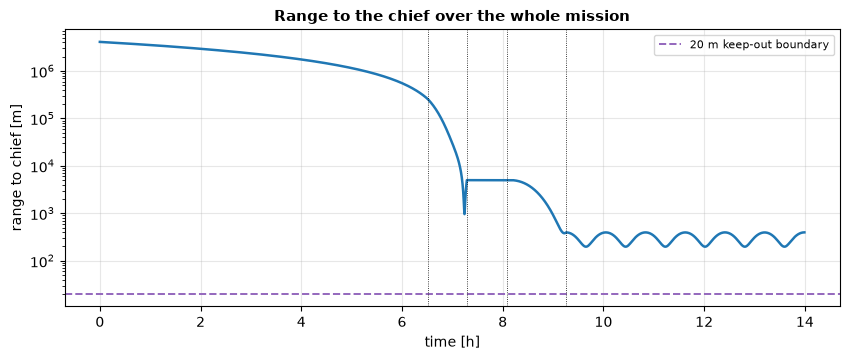

In [4]:
zone = KeepOutEllipsoid(a=20.0, b=20.0, c=20.0)

all_rel = np.concatenate([leg["rel"] for leg in legs], axis=1).T
all_t = np.concatenate([leg["t"] for leg in legs])

violated, margin, mask = check_trajectory(all_rel[:, :3], zone)
print(f"keep-out (20 m) over the whole mission: violated={violated}, margin={margin:.3f}")
print(f"closest approach: {np.linalg.norm(all_rel[:, :3], axis=1).min():.2f} m")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.semilogy(all_t / 3600, np.linalg.norm(all_rel[:, :3], axis=1), color=COL_ANA, lw=1.8)
ax.axhline(zone.a, color=COL_ZONE, lw=1.4, ls="--", label="20 m keep-out boundary")
for e in events:
    ax.axvline(e["t"] / 3600, color="k", lw=0.6, ls=":")
ax.set_xlabel("time [h]"); ax.set_ylabel("range to chief [m]")
ax.set_title("Range to the chief over the whole mission")
ax.legend(fontsize=8)
plt.show()

## Part B: passive safety of each burn

For each burn, what happens if it simply does not fire, given one orbit to notice and react.

In [5]:
print(f"{'burn':30s} {'violated':>9s} {'margin':>9s}")
for e in events:
    rel_before_m = inertial_to_lvlh(e["chief_before"], e["deputy_before"]) * 1e3
    v, m, _, _ = check_passive_safety(rel_before_m, n_c, zone, duration=T)
    print(f"{e['label']:30s} {str(v):>9s} {m:9.3f}")

burn                            violated    margin
Hohmann burn 1                     False -5495.380
Hohmann burn 2 (circularize)       False  -249.000
far-range burn (CW hop)            False  -245.574
ellipse insertion (CW)             False   -18.776


Every burn is passively safe, but by very different margins: the two Hohmann burns fail harmlessly from thousands of kilometres away, the far-range hop still has hundreds of metres of margin, and the ellipse insertion burn, the one meant to leave the deputy right next to its final safe orbit, has by far the tightest margin of the four. That burn is where Part E looks for probabilistic risk below.

## Part C: approach corridor on the far-range hop

The far-range hop is the one leg that is actually an approach, from the 5 km hold point in toward the chief; it is the natural target for a corridor check, here a generous 45 degree cone around the V-bar.

corridor (45 deg V-bar) on the far-range hop: violated=False, margin=-0.124 rad (-7.1 deg)


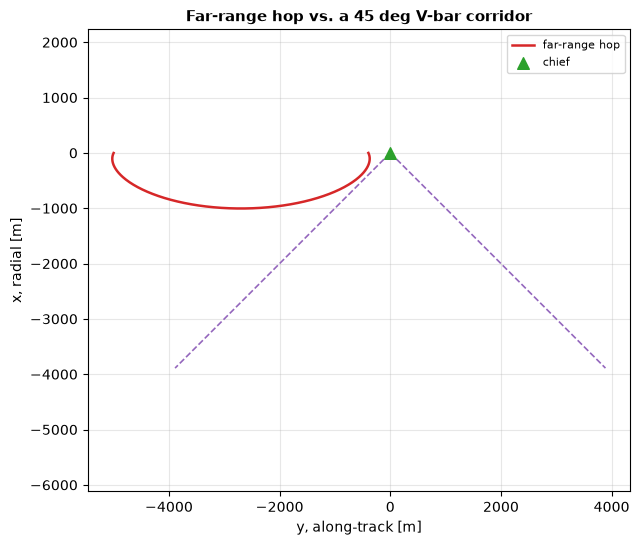

In [6]:
corridor = ApproachCorridor(direction=[0.0, -1.0, 0.0], half_angle=np.deg2rad(45.0))
hop_leg = next(leg for leg in legs if "far-range" in leg["label"])

violated, margin, mask = check_corridor(hop_leg["rel"][:3].T, corridor)
print(f"corridor (45 deg V-bar) on the far-range hop: violated={violated}, "
      f"margin={margin:+.3f} rad ({np.degrees(margin):+.1f} deg)")

fig, ax = plt.subplots(figsize=(7, 6))
ray_length, half_angle = 5500.0, corridor.half_angle
for sign in (-1, 1):
    ax.plot([0, sign * ray_length * np.sin(half_angle)], [0, -ray_length * np.cos(half_angle)],
             color=COL_ZONE, lw=1.2, ls="--")
ax.plot(hop_leg["rel"][1], hop_leg["rel"][0], color=COL_NUM, lw=1.8, label="far-range hop")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("Far-range hop vs. a 45 deg V-bar corridor")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(fontsize=8)
plt.show()

## Part D: J2 and the mission's actual ellipse

`safety_fundamentals.ipynb` ran this on a generic $\rho=100$ m ellipse entered at its near point. This mission's ellipse is $\rho=200$ m, entered at its far point ($\alpha=\pi/2$, the insertion phase chosen for the curvature-corrected hop), and the difference in where on the ellipse it starts turns out to matter.

In [7]:
pars_j2 = [MU_EARTH, J2_EARTH, R_EARTH]
dynamics_j2 = two_body_j2_dynamics_symbolic()


def coast_j2(chief, deputy, duration, pts=80):
    t_eval = np.linspace(0.0, duration, pts)
    c = propagate(dynamics_j2, chief, t_eval, pars=pars_j2).y[:, -1]
    d = propagate(dynamics_j2, deputy, t_eval, pars=pars_j2).y[:, -1]
    return c, d


rel0_m = state_design
rel0_km = np.concatenate([rel0_m[:3] / 1e3, rel0_m[3:] / 1e3])
chief_ell0 = circular_orbit_state(a_c, 0.0, incl)
deputy_ell0 = lvlh_to_inertial(chief_ell0, rel0_km)

n_orbits = 20
chief, deputy = chief_ell0, deputy_ell0
ranges_unc = [np.linalg.norm(rel0_m[:3])]
for _ in range(n_orbits):
    chief, deputy = coast_j2(chief, deputy, T)
    rel_m = inertial_to_lvlh(chief, deputy) * 1e3
    ranges_unc.append(np.linalg.norm(rel_m[:3]))

tof_corr = 0.9 * T
chief, deputy = chief_ell0, deputy_ell0
dv_per_orbit = []
for _ in range(n_orbits):
    chief, deputy = coast_j2(chief, deputy, T)
    rel_actual_m = inertial_to_lvlh(chief, deputy) * 1e3
    dv1, dv2 = cw_targeting(rel_actual_m[:3], rel_actual_m[3:], rel0_m[:3], rel0_m[3:], tof_corr, n_c)
    deputy[3:] += to_inertial_dv(chief, dv1)
    chief, deputy = coast_j2(chief, deputy, tof_corr)
    deputy[3:] += to_inertial_dv(chief, dv2)
    dv_per_orbit.append(np.linalg.norm(dv1) + np.linalg.norm(dv2))

print(f"range-only view: {ranges_unc[0]:.2f} m at t=0, {ranges_unc[-1]:.2f} m after {n_orbits} orbits "
      f"(barely moves: the far point of an ellipse is where range is least sensitive to phase)")
print(f"but the full-state station-keeping cost to hold this ellipse: "
      f"{sum(dv_per_orbit) / n_orbits * 1e3:.1f} mm/s per orbit")

range-only view: 400.00 m at t=0, 400.85 m after 20 orbits (barely moves: the far point of an ellipse is where range is least sensitive to phase)
but the full-state station-keeping cost to hold this ellipse: 436.9 mm/s per orbit


Range alone says almost nothing is happening: the mission's ellipse is entered at its far point, where range against orbital phase is locally flat, so a phase drift that would show up clearly at the near point barely moves the range number here. The actual relative state still drifts enough that holding it costs real delta-v, about seven times more per orbit than the generic example in `safety_fundamentals.ipynb`. Range is a convenient proxy for Part A's keep-out check, but Part D is a reminder that it is not a substitute for checking the full state when the question is whether a design is holding, not just whether it is colliding.

## Part E: collision probability at the tightest margin

Part B found the insertion burn to have the tightest passive-safety margin of the four. The deterministic check there only looks at the nominal trajectory; this section asks what a realistic navigation and burn-execution uncertainty does to that same point, propagated through the closed-form CW state transition matrix rather than a nonlinear integration, which is what keeps a Monte Carlo of tens of thousands of samples cheap.

Pc over one orbit on the ellipse, nav_sigma=10 m, burn_vel_sigma=10 mm/s: 2.364e-02


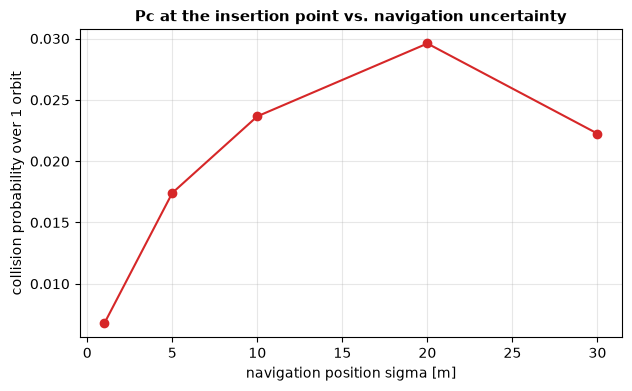

In [8]:
state_at_insertion = legs[-1]["rel"][:, 0]   # right after the insertion burn
rng = np.random.default_rng(0)

nav_sigma = 10.0       # m, relative-navigation position uncertainty
burn_vel_sigma = 0.01  # m/s, residual burn-execution velocity uncertainty

cov = np.eye(6)
cov[:3, :3] *= nav_sigma**2
cov[3:, 3:] *= burn_vel_sigma**2

t_eval_pc = np.linspace(0, T, 50)
pc = collision_probability(state_at_insertion, cov, n_c, t_eval_pc, zone, n_samples=100000, rng=rng)
print(f"Pc over one orbit on the ellipse, nav_sigma={nav_sigma:.0f} m, "
      f"burn_vel_sigma={burn_vel_sigma*1e3:.0f} mm/s: {pc:.3e}")

sigmas = np.array([1.0, 5.0, 10.0, 20.0, 30.0])
pcs = []
for s in sigmas:
    cov_s = np.eye(6)
    cov_s[:3, :3] *= s**2
    cov_s[3:, 3:] *= burn_vel_sigma**2
    pcs.append(collision_probability(state_at_insertion, cov_s, n_c, t_eval_pc, zone, n_samples=100000, rng=rng))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigmas, pcs, color=COL_NUM, marker="o")
ax.set_xlabel("navigation position sigma [m]"); ax.set_ylabel("collision probability over 1 orbit")
ax.set_title("Pc at the insertion point vs. navigation uncertainty")
plt.show()

The deterministic margin at this point was comfortably negative (safe) in Part B. Yet with a realistic 10 m navigation uncertainty and a small 1 cm/s residual burn error, a non-trivial fraction of possible outcomes enter the 20 m zone at some point during the following orbit. The reason is not the position uncertainty by itself: it is that a small velocity error, carried through the CW state transition matrix over most of an orbit, gets amplified into a position spread far larger than the velocity error alone would suggest, the same amplification that made short-time-of-flight corrections so expensive in `cw_fundamentals.ipynb` and in Part D above. A deterministic check on the nominal trajectory alone would have missed this; it needs an explicit uncertainty model to show up at all.

## Summary

Run deterministically, this mission clears every check built in `safety_fundamentals.ipynb`: the keep-out zone, passive safety on all four burns, the approach corridor on the far-range hop, and J2 station-keeping on the final ellipse, all with margin to spare. The probabilistic check in Part E tells a different story at the exact point that looked safest in relative terms: once realistic navigation and burn-execution uncertainty are added, the insertion point carries a collision probability that the deterministic margin never revealed, because the risk comes from how the dynamics amplifies velocity error over time, not from the nominal trajectory being close to the chief.

That is the reason layer 2 needed five checks and not one: each one here caught, or would have caught, something the others do not, across both this real mission and the toy examples in `safety_fundamentals.ipynb`. What they feed forward is also now in hand for layer 3: a delta-v budget line for station-keeping, a mission that is deterministically safe, and a concrete number for how much that safety depends on navigation performance that still has to be assumed, not derived, at this stage.